Processing ethiopia...


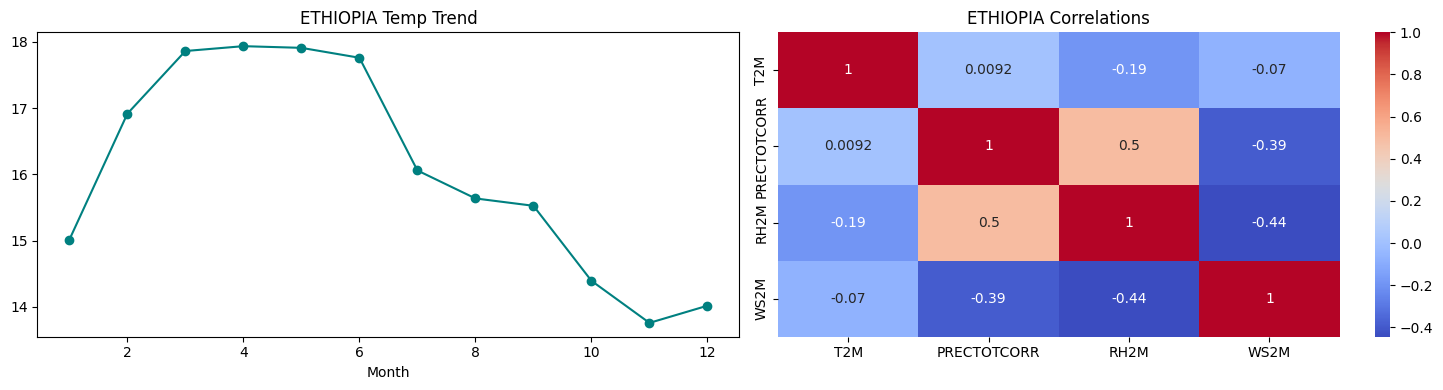

Processing kenya...


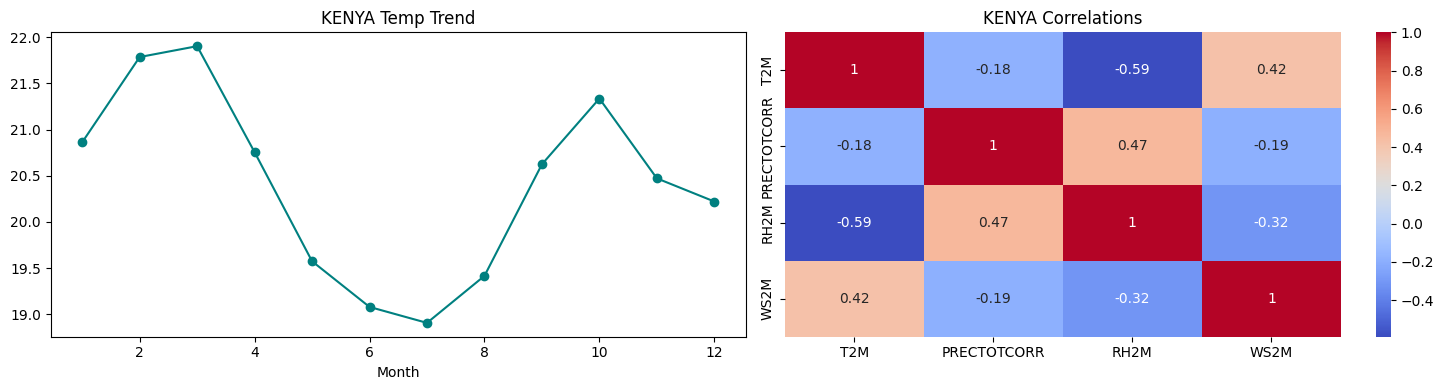

Processing nigeria...


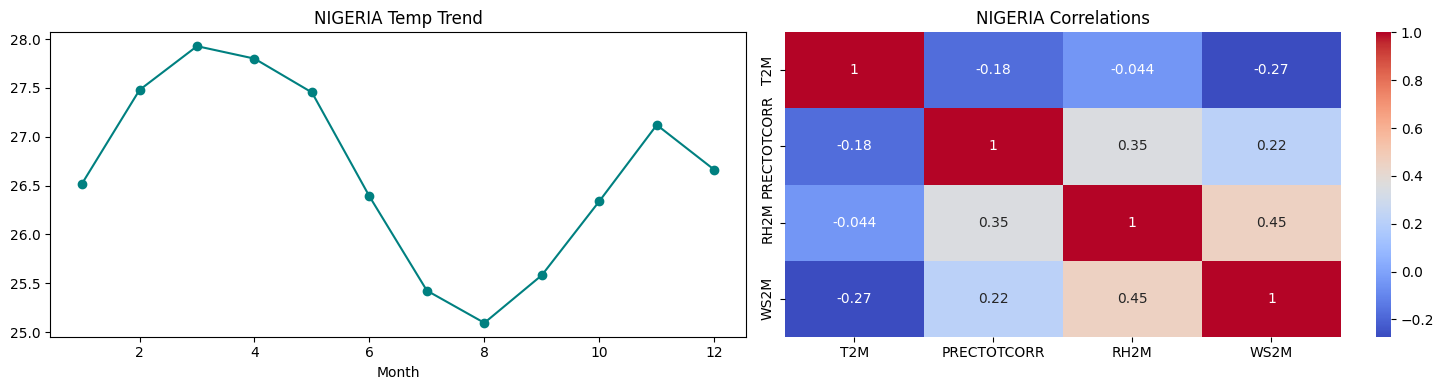

Processing sudan...


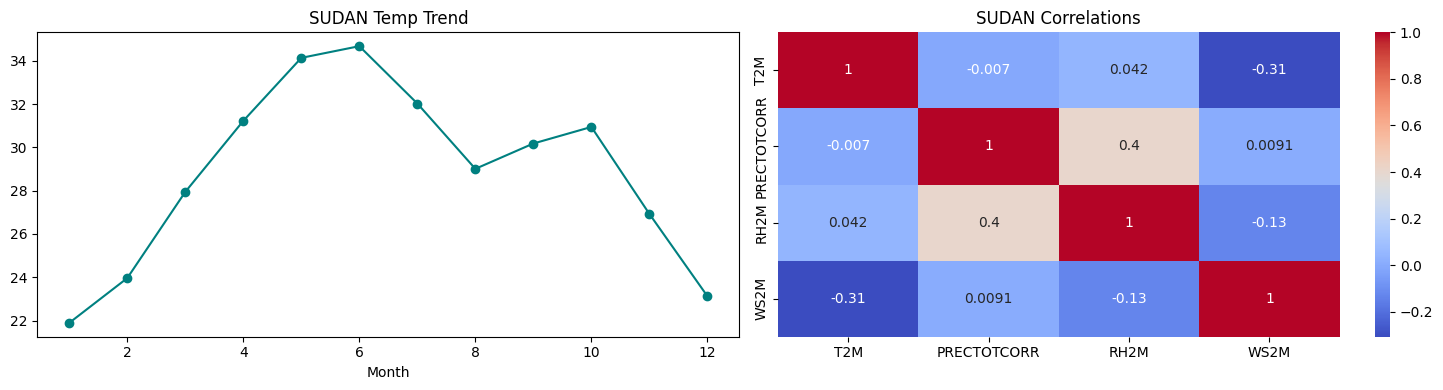

Processing tanzania...


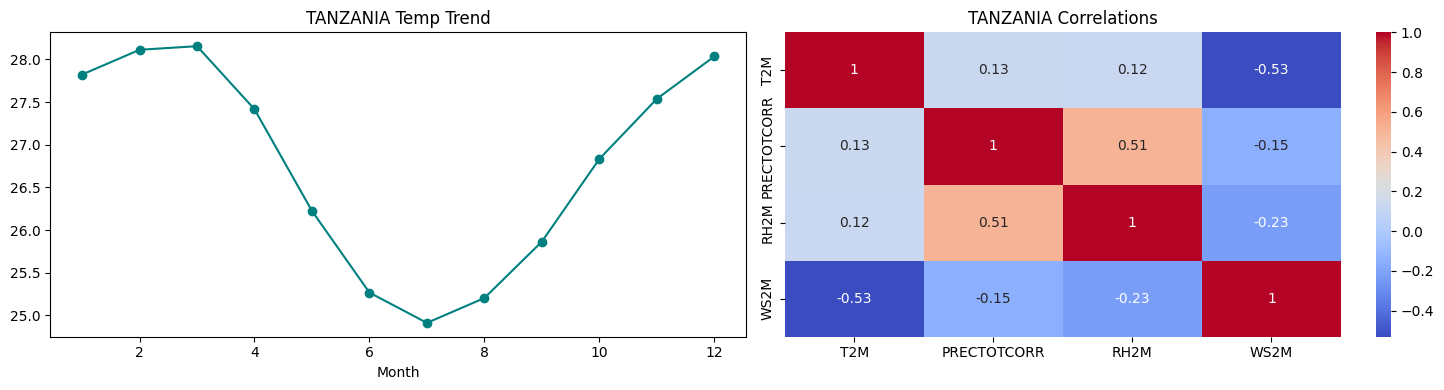

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

countries = ['ethiopia', 'kenya', 'nigeria', 'sudan', 'tanzania']

for country in countries:
    print(f"Processing {country}...")
    # Load necessary columns
    df = pd.read_csv(f'../data/{country}.csv')
    df.replace(-999, np.nan, inplace=True)
    
    df['Month'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j').dt.month

    # Create a figure with two parts (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    
    # 1. Line Chart on the left
    df.groupby('Month')['T2M'].mean().plot(kind='line', marker='o', ax=ax1, color='teal')
    ax1.set_title(f'{country.upper()} Temp Trend')
    
    # 2. Heatmap on the right
    sns.heatmap(df[['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr(), annot=True, cmap='coolwarm', ax=ax2)
    ax2.set_title(f'{country.upper()} Correlations')
    
    plt.tight_layout()
    plt.show()